In [1]:
import numpy as np
import matplotlib.pyplot as plt

results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
data0 = np.load(results_loc+'W_reg_factors/W_0.npy')
print(data0.shape)
data1 = np.load(results_loc+'W_reg_factors/W_1.npy')
print(data1.shape)
data2 = np.load(results_loc+'W_reg_factors/W_2.npy')
print(data2.shape)
data3 = np.load(results_loc+'W_reg_factors/W_3.npy')
print(data3.shape)
data_b = np.concatenate((data0,data1,data2,data3), axis=0)
print(data_b.shape)

(1379, 5)
(1379, 5)
(1379, 5)
(1378, 5)
(5515, 5)


In [2]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
data0 = np.load(results_loc+'W_reg_factors/W_0.npy')
print(data0.shape)
data1 = np.load(results_loc+'W_reg_factors/W_1.npy')
print(data1.shape)
data2 = np.load(results_loc+'W_reg_factors/W_2.npy')
print(data2.shape)
data3 = np.load(results_loc+'W_reg_factors/W_3.npy')
print(data3.shape)
data_t = np.concatenate((data0,data1,data2,data3), axis=0)
print(data_t.shape)

(1828, 7)
(1828, 7)
(1828, 7)
(1828, 7)
(7312, 7)


In [3]:
import pandas as pd
df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]

df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]

pivot_1 = pd.read_csv('/home/shic892/corems/Pivot_Metdata.csv', header=0, index_col=0)
pivot_2 = pd.read_csv('/tahoma/emsls60141/FT-ICR-MS/results/2022_11_Pivot_Metdata.csv', header=0, index_col=0)

df_sites_qc_top

,C10 H10 O5,C10 H10 O5 N2,C10 H10 O6,C10 H10 O6 N2,C10 H10 O7,C10 H10 O8,C10 H10 O9,C10 H11 O4 N1,C10 H11 O5 N1,C10 H11 O6 N1,...,C9 H5 O8 N1,C9 H5 O9 N1,C9 H6 O10,C9 H6 O6 N2,C9 H6 O7 N2,C9 H6 O8 N2,C9 H8 O7 N2,C9 H8 O8 N2,C9 H8 O9,C9 H9 O7 N1
short,,,,,,,,,,,,,,,,,,,,,
ANZA_TOP,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BLAN_TOP,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFS1_TOP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFS2_TOP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CLBJ_TOP,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WY01_TOP,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WY03_TOP,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
WY09_TOP,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
pivot_all = pd.concat([pivot_1, pivot_2])
print(pivot_1.shape, pivot_2.shape, pivot_all.shape)

(84408, 12) (106666, 12) (191074, 12)


In [5]:
pivot_all = pivot_all.groupby(pivot_all.index).first()
# df[~df.index.duplicated()]

In [6]:
df_pivot_top = pivot_all.loc[list(df_sites_qc_top),:]
del df_pivot_top['Filename']
df_pivot_top

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class
Molecular Formula,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,NaN,NaN,209.045547,6.0,1.000000,0.500000,O5
C10 H10 O5 N2,4430,10.0,10.0,5.0,NaN,2.0,237.051695,7.0,1.000000,0.500000,N2 O5
C10 H10 O6,4480,10.0,10.0,6.0,NaN,NaN,225.040462,6.0,1.000000,0.600000,O6
C10 H10 O6 N2,4329,10.0,10.0,6.0,NaN,2.0,253.046610,7.0,1.000000,0.600000,N2 O6
C10 H10 O7,4409,10.0,10.0,7.0,NaN,NaN,241.035376,6.0,1.000000,0.700000,O7
...,...,...,...,...,...,...,...,...,...,...,...
C9 H6 O8 N2,22869,9.0,6.0,8.0,NaN,2.0,269.005139,8.0,0.666667,0.888889,N2 O8
C9 H8 O7 N2,4317,9.0,8.0,7.0,NaN,2.0,255.025874,7.0,0.888889,0.777778,N2 O7
C9 H8 O8 N2,19693,9.0,8.0,8.0,NaN,2.0,271.020789,7.0,0.888889,0.888889,N2 O8


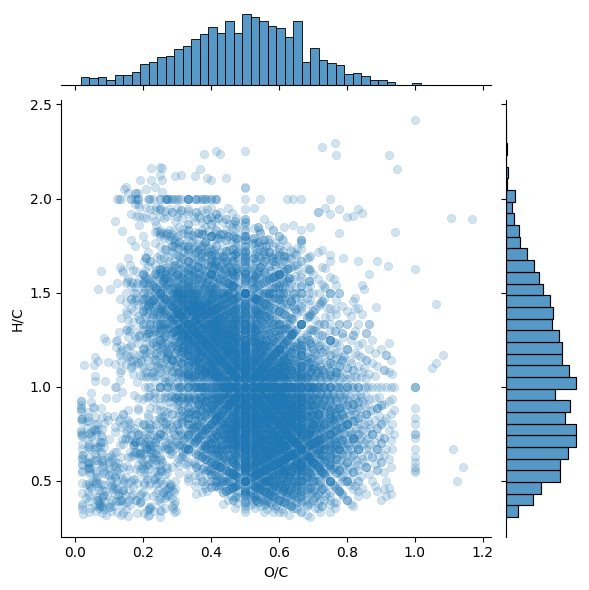

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
vkplot = sns.jointplot(data=df_pivot_top,x='O/C',y='H/C',
             joint_kws={'edgecolor':None,
                       'alpha':0.2})
plt.show()

In [7]:
df_pivot_btm = pivot_all.loc[list(df_sites_qc_btm),:]
del df_pivot_btm['Filename']
df_pivot_btm

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class
Molecular Formula,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,NaN,NaN,209.045547,6.0,1.000000,0.500000,O5
C10 H10 O5 S1,11844,10.0,10.0,5.0,1.0,NaN,241.017618,6.0,1.000000,0.500000,S1 O5
C10 H10 O6,4480,10.0,10.0,6.0,NaN,NaN,225.040462,6.0,1.000000,0.600000,O6
C10 H10 O7,4409,10.0,10.0,7.0,NaN,NaN,241.035376,6.0,1.000000,0.700000,O7
C10 H10 O8,4299,10.0,10.0,8.0,NaN,NaN,257.030291,6.0,1.000000,0.800000,O8
...,...,...,...,...,...,...,...,...,...,...,...
C8 H16 O6 S1,4810,8.0,16.0,6.0,1.0,NaN,239.059483,1.0,2.000000,0.750000,S1 O6
C8 H18 O3 S2,11277,8.0,18.0,3.0,2.0,NaN,225.062460,0.0,2.250000,0.375000,S2 O3
C8 H5 O6 N1,4538,8.0,5.0,6.0,NaN,1.0,210.004410,7.0,0.625000,0.750000,N1 O6


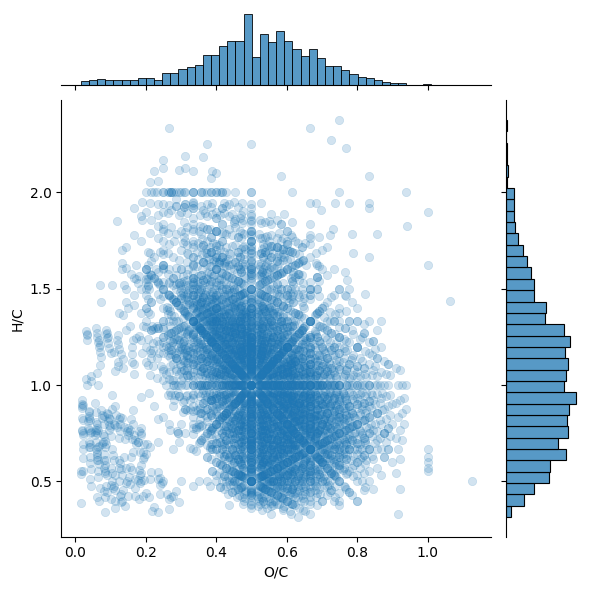

In [7]:

vkplot = sns.jointplot(data=df_pivot_btm,x='O/C',y='H/C',
             joint_kws={'edgecolor':None,
                       'alpha':0.2})
plt.show()

In [13]:
Hmass = 1.007825
emass = 5.485e-4
deprotonatedmass = Hmass-emass

def elcomp(dataseries):
    elcomps = []
    for i in range(len(dataseries)):
        elcomp = ''
        for x in ['C','H','O','N','S','P']:
            try:
                if dataseries.iloc[i][x]>0:
                    elcomp += x
            except:
                None
        elcomps.append(elcomp)
    return elcomps

def classcalc(dataseries): #from https://github.com/PNNL-Comp-Mass-Spec/Formularity/blob/master/CIA/FormularityProgram.cs
    cmpclasses = []
    for i in range(len(dataseries)):
        HC = dataseries.iloc[i]['H/C']
        OC = dataseries.iloc[i]['O/C']
        if (HC>=1.5) & (HC<2.5) & (OC>=0) & (OC<0.3):
            cmpclass = 'lipid'
        elif (HC>=0.8) & (HC<1.5) & (OC>=0) & (OC<0.125):
            cmpclass = 'unsatHC'
        elif (HC>=0.2) & (HC<0.8) & (OC>=0) & (OC<0.95):
            cmpclass = 'condHC'
        elif (HC>=1.5) & (HC<2.3) & (OC>=0.3) & (OC<0.55):
            cmpclass = 'protein'    
        elif (HC>=1.5) & (HC<2.2) & (OC>=0.55) & (OC<0.7):
            cmpclass = 'aminosugar'    
        elif (HC>=1.5) & (HC<2.2) & (OC>=0.7) & (OC<1.05):
            cmpclass = 'carb'
        elif (HC>=0.8) & (HC<1.5) & (OC>=0.125) & (OC<0.65):
            cmpclass = 'lignin'
        elif (HC>=0.8) & (HC<1.5) & (OC>=0.65) & (OC<1.1):
            cmpclass = 'tanin'
        else:
            cmpclass = 'undefined'
        cmpclasses.append(cmpclass)  
    return cmpclasses

In [14]:
df_pivot_top['Class'] = classcalc(df_pivot_top)
df_pivot_top['El_comp'] = elcomp(df_pivot_top)
df_pivot_top['NeutralMass'] = df_pivot_top['Calculated m/z']+deprotonatedmass
df_pivot_top

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class,Class,El_comp,NeutralMass
Molecular Formula,,,,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,NaN,NaN,209.045547,6.0,1.000000,0.500000,O5,lignin,CHO,210.052823
C10 H10 O5 N2,4430,10.0,10.0,5.0,NaN,2.0,237.051695,7.0,1.000000,0.500000,N2 O5,lignin,CHON,238.058971
C10 H10 O6,4480,10.0,10.0,6.0,NaN,NaN,225.040462,6.0,1.000000,0.600000,O6,lignin,CHO,226.047738
C10 H10 O6 N2,4329,10.0,10.0,6.0,NaN,2.0,253.046610,7.0,1.000000,0.600000,N2 O6,lignin,CHON,254.053886
C10 H10 O7,4409,10.0,10.0,7.0,NaN,NaN,241.035376,6.0,1.000000,0.700000,O7,tanin,CHO,242.042653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C9 H6 O8 N2,22869,9.0,6.0,8.0,NaN,2.0,269.005139,8.0,0.666667,0.888889,N2 O8,condHC,CHON,270.012415
C9 H8 O7 N2,4317,9.0,8.0,7.0,NaN,2.0,255.025874,7.0,0.888889,0.777778,N2 O7,tanin,CHON,256.033151
C9 H8 O8 N2,19693,9.0,8.0,8.0,NaN,2.0,271.020789,7.0,0.888889,0.888889,N2 O8,tanin,CHON,272.028065


In [17]:
df_pivot_top.fillna(0, inplace=True)
df_pivot_top['NOSC'] = -((4*df_pivot_top['C']+df_pivot_top['H']-3*df_pivot_top['N']-2*df_pivot_top['O']-2*df_pivot_top['S'])/df_pivot_top['C'])+4
df_pivot_top['GFE'] = 60.3-28.5*df_pivot_top['NOSC']
df_pivot_top

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class,Class,El_comp,NeutralMass,NOSC,GFE
Molecular Formula,,,,,,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,0.0,0.0,209.045547,6.0,1.000000,0.500000,O5,lignin,CHO,210.052823,0.000000,60.300000
C10 H10 O5 N2,4430,10.0,10.0,5.0,0.0,2.0,237.051695,7.0,1.000000,0.500000,N2 O5,lignin,CHON,238.058971,0.600000,43.200000
C10 H10 O6,4480,10.0,10.0,6.0,0.0,0.0,225.040462,6.0,1.000000,0.600000,O6,lignin,CHO,226.047738,0.200000,54.600000
C10 H10 O6 N2,4329,10.0,10.0,6.0,0.0,2.0,253.046610,7.0,1.000000,0.600000,N2 O6,lignin,CHON,254.053886,0.800000,37.500000
C10 H10 O7,4409,10.0,10.0,7.0,0.0,0.0,241.035376,6.0,1.000000,0.700000,O7,tanin,CHO,242.042653,0.400000,48.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C9 H6 O8 N2,22869,9.0,6.0,8.0,0.0,2.0,269.005139,8.0,0.666667,0.888889,N2 O8,condHC,CHON,270.012415,1.777778,9.633333
C9 H8 O7 N2,4317,9.0,8.0,7.0,0.0,2.0,255.025874,7.0,0.888889,0.777778,N2 O7,tanin,CHON,256.033151,1.333333,22.300000
C9 H8 O8 N2,19693,9.0,8.0,8.0,0.0,2.0,271.020789,7.0,0.888889,0.888889,N2 O8,tanin,CHON,272.028065,1.555556,15.966667


In [16]:
df_pivot_btm['Class'] = classcalc(df_pivot_btm)
df_pivot_btm['El_comp'] = elcomp(df_pivot_btm)
df_pivot_btm['NeutralMass'] = df_pivot_btm['Calculated m/z']+deprotonatedmass
df_pivot_btm

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class,Class,El_comp,NeutralMass
Molecular Formula,,,,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,NaN,NaN,209.045547,6.0,1.000000,0.500000,O5,lignin,CHO,210.052823
C10 H10 O5 S1,11844,10.0,10.0,5.0,1.0,NaN,241.017618,6.0,1.000000,0.500000,S1 O5,lignin,CHOS,242.024895
C10 H10 O6,4480,10.0,10.0,6.0,NaN,NaN,225.040462,6.0,1.000000,0.600000,O6,lignin,CHO,226.047738
C10 H10 O7,4409,10.0,10.0,7.0,NaN,NaN,241.035376,6.0,1.000000,0.700000,O7,tanin,CHO,242.042653
C10 H10 O8,4299,10.0,10.0,8.0,NaN,NaN,257.030291,6.0,1.000000,0.800000,O8,tanin,CHO,258.037567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C8 H16 O6 S1,4810,8.0,16.0,6.0,1.0,NaN,239.059483,1.0,2.000000,0.750000,S1 O6,carb,CHOS,240.066759
C8 H18 O3 S2,11277,8.0,18.0,3.0,2.0,NaN,225.062460,0.0,2.250000,0.375000,S2 O3,protein,CHOS,226.069737
C8 H5 O6 N1,4538,8.0,5.0,6.0,NaN,1.0,210.004410,7.0,0.625000,0.750000,N1 O6,condHC,CHON,211.011687


In [18]:
df_pivot_btm.fillna(0, inplace=True)
df_pivot_btm['NOSC'] = -((4*df_pivot_btm['C']+df_pivot_btm['H']-3*df_pivot_btm['N']-2*df_pivot_btm['O']-2*df_pivot_btm['S'])/df_pivot_btm['C'])+4
df_pivot_btm['GFE'] = 60.3-28.5*df_pivot_btm['NOSC']
df_pivot_btm

,Index,C,H,O,S,N,Calculated m/z,DBE,H/C,O/C,Heteroatom Class,Class,El_comp,NeutralMass,NOSC,GFE
Molecular Formula,,,,,,,,,,,,,,,,
C10 H10 O5,4541,10.0,10.0,5.0,0.0,0.0,209.045547,6.0,1.000000,0.500000,O5,lignin,CHO,210.052823,0.000000,60.300000
C10 H10 O5 S1,11844,10.0,10.0,5.0,1.0,0.0,241.017618,6.0,1.000000,0.500000,S1 O5,lignin,CHOS,242.024895,0.200000,54.600000
C10 H10 O6,4480,10.0,10.0,6.0,0.0,0.0,225.040462,6.0,1.000000,0.600000,O6,lignin,CHO,226.047738,0.200000,54.600000
C10 H10 O7,4409,10.0,10.0,7.0,0.0,0.0,241.035376,6.0,1.000000,0.700000,O7,tanin,CHO,242.042653,0.400000,48.900000
C10 H10 O8,4299,10.0,10.0,8.0,0.0,0.0,257.030291,6.0,1.000000,0.800000,O8,tanin,CHO,258.037567,0.600000,43.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C8 H16 O6 S1,4810,8.0,16.0,6.0,1.0,0.0,239.059483,1.0,2.000000,0.750000,S1 O6,carb,CHOS,240.066759,-0.250000,67.425000
C8 H18 O3 S2,11277,8.0,18.0,3.0,2.0,0.0,225.062460,0.0,2.250000,0.375000,S2 O3,protein,CHOS,226.069737,-1.000000,88.800000
C8 H5 O6 N1,4538,8.0,5.0,6.0,0.0,1.0,210.004410,7.0,0.625000,0.750000,N1 O6,condHC,CHON,211.011687,1.250000,24.675000


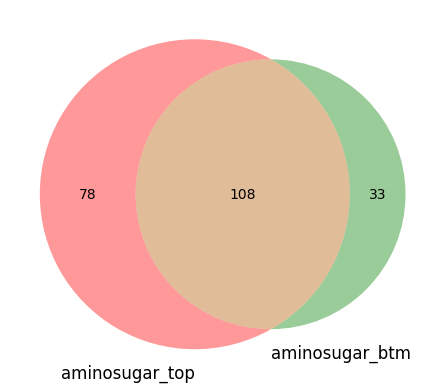

In [16]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = set(df_pivot_top[df_pivot_top.Class=='aminosugar'].index.values)
set2 = set(df_pivot_btm[df_pivot_btm.Class=='aminosugar'].index.values)

venn2([set1, set2], ('aminosugar_top', 'aminosugar_btm'))

plt.show()

In [19]:
data_norm_t = data_t/data_t.max(axis=0)
print(data_norm_t.shape)

(7312, 7)


In [20]:
data_norm_b = data_b/data_b.max(axis=0)
print(data_norm_b.shape)

(5515, 5)


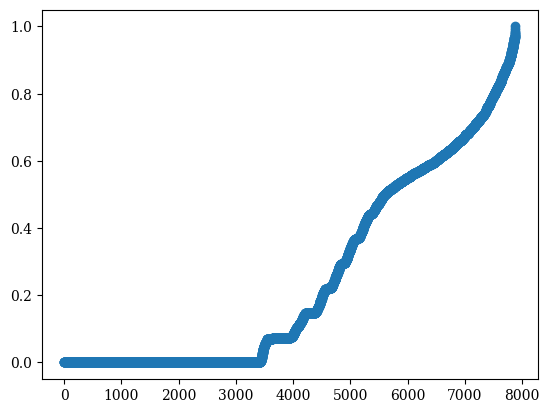

In [23]:
plt.rc('font', family='serif')
plt.plot(range(0,7880),data_norm[:,0][np.argsort(data_norm[:,0])], 'o-')
plt.show()

In [13]:
print(np.sum((data_norm_t>0.5), axis=0))
print(data_norm_t[np.sum((data_norm_t>0.5), axis=1)>0].shape)
print(np.sum((data_norm_t>0.6), axis=0))
print(data_norm_t[np.sum((data_norm_t>0.6), axis=1)>0].shape)
print(np.sum((data_norm_t>0.7), axis=0))
print(data_norm_t[np.sum((data_norm_t>0.7), axis=1)>0].shape)
print(np.sum((data_norm_t>0.8), axis=0))
print(data_norm_t[np.sum((data_norm_t>0.8), axis=1)>0].shape)

[1604  831  348 1335  851 1810 2366]
(3417, 7)
[1248  533  267  510  582 1275 1805]
(3061, 7)
[582 235 205 183 117 484 850]
(2045, 7)
[204  82 130  96  54  92 360]
(981, 7)


In [21]:
print(np.sum((data_norm_t>0.5), axis=0))

[1604  831  348 1335  851 1810 2366]


In [22]:
min(np.max(data_norm_b[np.sum((data_norm_b>0.5), axis=1)>0], axis=1))

0.5000716338765518

In [19]:
np.savetxt('1000s_top_7nmf_W_05_3417x7.csv', data_norm_t[np.sum((data_norm_t>0.5), axis=1)>0], delimiter=",")

In [20]:
data_norm_b[np.sum((data_norm_b>0.5), axis=1)>0].shape

(2222, 5)

In [25]:
!pwd

/home/shic892/pyDNMFk/examples


In [21]:
data_norm_t[np.sum((data_norm_t>0.5), axis=1)>0].shape

(3417, 7)

In [23]:
np.savetxt('1000s_btm_5nmf_W_05_2222x5.csv', data_norm_b[np.sum((data_norm_b>0.5), axis=1)>0].shape, delimiter=",")

In [22]:
df_pivot_top_sig = df_pivot_top[np.sum((data_norm_t>0.5), axis=1)>0]
df_pivot_top_sig_lig = df_pivot_top_sig[df_pivot_top_sig.Class=='lignin']
df_pivot_top_sig_lig.index

Index(['C10 H10 O5', 'C10 H10 O6', 'C10 H11 O5 N1', 'C10 H11 O6 N1',
       'C10 H12 O5', 'C10 H12 O6', 'C10 H12 O6 N2', 'C10 H13 O6 N1',
       'C10 H8 O5', 'C10 H8 O6',
       ...
       'C37 H52 O13', 'C38 H52 O15', 'C9 H9 O5 N1', 'C12 H16 O7 N2',
       'C13 H16 O5', 'C14 H14 O7', 'C16 H20 O8', 'C22 H29 O9 N1',
       'C24 H31 O7 N1', 'C34 H29 O12 S1 N2 P1'],
      dtype='object', name='Molecular Formula', length=1729)

In [24]:
df_pivot_btm_sig = df_pivot_btm[np.sum((data_norm_b>0.5), axis=1)>0]
df_pivot_btm_sig_lig = df_pivot_btm_sig[df_pivot_btm_sig.Class=='lignin']
df_pivot_btm_sig_lig.index

Index(['C10 H10 O5', 'C10 H10 O6', 'C10 H12 O5', 'C10 H12 O6', 'C10 H12 O6 N2',
       'C10 H8 O5', 'C10 H8 O6', 'C11 H10 O4', 'C11 H10 O5', 'C11 H10 O6',
       ...
       'C34 H44 O15', 'C35 H34 O21', 'C35 H40 O18', 'C35 H42 O17',
       'C37 H45 O11 P1', 'C38 H33 O13 S1 N2 P1', 'C13 H16 O5', 'C14 H14 O7',
       'C16 H20 O8', 'C24 H31 O7 N1'],
      dtype='object', name='Molecular Formula', length=1151)

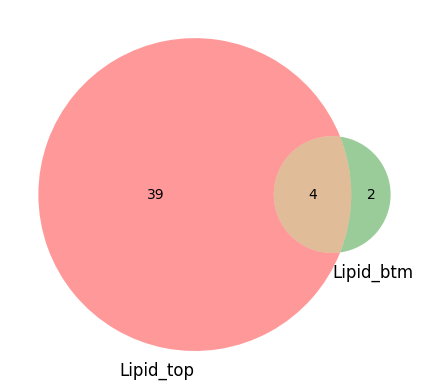

In [38]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = set(df_pivot_top_sig[df_pivot_top_sig.Class=='lipid'].index.values)
set2 = set(df_pivot_btm_sig[df_pivot_btm_sig.Class=='lipid'].index.values)

venn2([set1, set2], ('Lipid_top', 'Lipid_btm'))

plt.show()

In [12]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']
df_sum = pd.DataFrame(columns=df_pivot_top.Class.unique(),index=NMFs)
for i in range(7):
    dfi = df_pivot_top[data_norm_t[:,i]>0.5]['Class'].value_counts()
    df_sum.loc[NMFs[i], dfi.index] = dfi

df_sum

,lignin,tanin,protein,aminosugar,carb,condHC,undefined,lipid,unsatHC
NMF1,926,174,96,28,3,370,2,5,NaN
NMF2,450,135,27,5,NaN,209,1,4,NaN
NMF3,209,85,NaN,NaN,NaN,54,NaN,NaN,NaN
NMF4,967,102,87,16,1,123,NaN,39,NaN
NMF5,380,164,NaN,1,NaN,306,NaN,NaN,NaN
NMF6,863,237,70,23,5,598,3,11,NaN
NMF7,1166,289,38,18,3,848,2,2,NaN


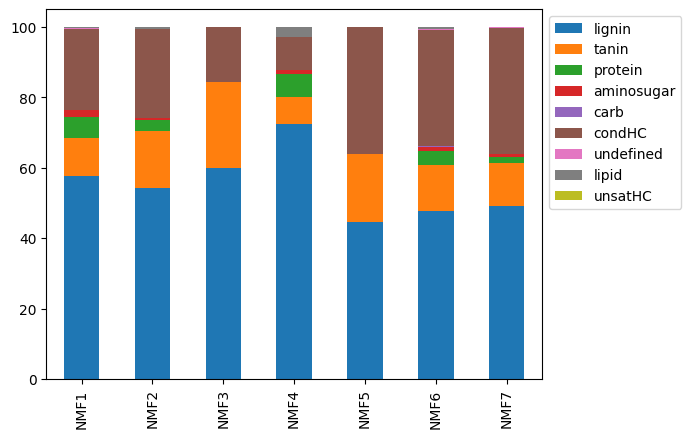

In [11]:
df_sum = df_sum.replace(np.nan, 0)
df_sum_rel = df_sum.divide(df_sum.sum(axis=1),axis=0)*100

import seaborn as sns
palette = sns.color_palette().as_hex()
axes = df_sum_rel.plot.bar(stacked=True, color=palette[0:9])
axes.legend(bbox_to_anchor= (1, 1)) 

In [12]:
data_norm[np.sum((data_norm>0.5), axis=1)>0].shape

(3417, 7)

In [24]:
data_norm_by_class = np.array([NMFs])
class_list = np.array(['Class'])
for cls in df_pivot.Class.unique():
    df_class = data_norm[df_pivot.Class==cls,:]
    df_class = df_class[np.sum((df_class>0.5), axis=1)>0]
    data_norm_by_class = np.concatenate([data_norm_by_class, df_class], axis=0)
    class_list = np.append(class_list, np.repeat(cls, df_class.shape[0]))
    print(len(class_list))


1730
2145
2279
2314
2320
3372
3375
3418
3418


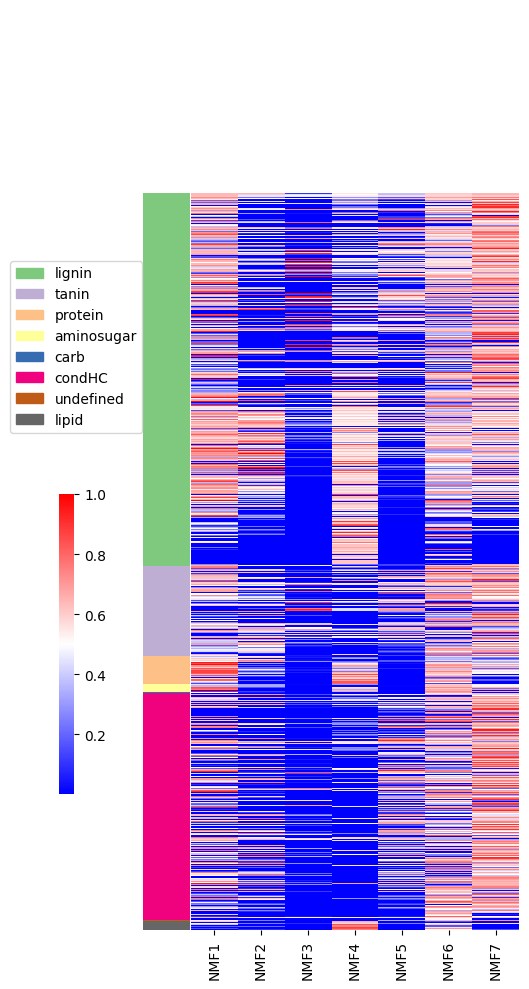

In [75]:
colors = plt.get_cmap('Accent').colors
sp_s = class_list[1:]
lut_s = dict(zip(pd.Series(sp_s).unique(), colors))
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(data_norm_by_class[1:,:].astype(float), figsize=(5,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=False, row_colors=rowc_s, cbar_pos=(0.05, .2, .03, .3))
#g.ax_col_dendrogram.legend(loc="upper left", bbox_to_anchor=(0.5, 1.15))
handles = [plt.Rectangle((0,0),1,1, color=lut_s[label]) for label in lut_s]
plt.legend(handles, lut_s.keys(),loc="upper right", bbox_to_anchor=(6, 1.8), ncol=1)

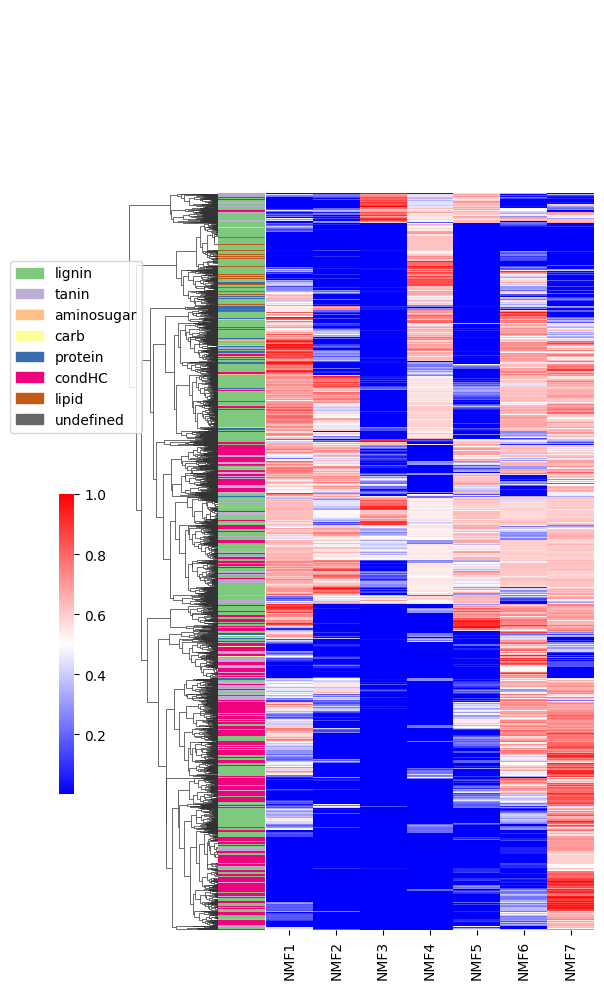

In [81]:

data_norm_plot = data_norm[np.sum((data_norm>0.5), axis=1)>0]

sp_s = df_pivot.iloc[np.sum((data_norm>0.5), axis=1)>0,:]['Class']
colors = plt.get_cmap('Accent').colors

lut_s = dict(zip(pd.Series(sp_s).unique(), colors))
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(data_norm_plot, figsize=(5,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=True, row_colors=rowc_s, cbar_pos=(-0.1, .2, .03, .3))
#g.ax_col_dendrogram.legend(loc="upper left", bbox_to_anchor=(0.5, 1.15))
handles = [plt.Rectangle((0,0),1,1, color=lut_s[label]) for label in lut_s]
plt.legend(handles, lut_s.keys(),loc="upper right", bbox_to_anchor=(6, 1.8), ncol=1)
#sns.clustermap(data_norm_plot, figsize=(5,8), cmap="vlag",col_cluster=False)

In [22]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']
#NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
data_norm_t = pd.DataFrame(data_norm_t, columns=NMFs, index=df_pivot_top.index.values)
data_norm_t

,NMF1,NMF2,NMF3,NMF4,NMF5,NMF6,NMF7
C10 H10 O5,0.636544,0.651607,0.100836,0.552998,0.381349,0.601745,0.640047
C10 H10 O5 N2,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.099312
C10 H10 O6,0.625494,0.478985,0.383961,0.557491,0.366484,0.592367,0.647934
C10 H10 O6 N2,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.099102
C10 H10 O7,0.626151,0.707454,0.138994,0.543832,0.434315,0.614383,0.617045
...,...,...,...,...,...,...,...
C9 H6 O8 N2,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.099953
C9 H8 O7 N2,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.098592
C9 H8 O8 N2,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.099909
C9 H8 O9,0.000004,0.000003,0.000002,0.000003,0.000003,0.000004,0.000004


In [37]:
nosc_concat = []
group_concat = []
for i in NMFs:
    nosc_i = df_pivot_top[data_norm_t[i]>0.5]['NOSC'].values.tolist()
    nosc_concat.extend(nosc_i)
    print(len(nosc_i))
    group_concat.extend(np.repeat(i, len(nosc_i)))

1604
831
348
1335
851
1810
2366


<AxesSubplot:xlabel='NMFs', ylabel='nosc'>

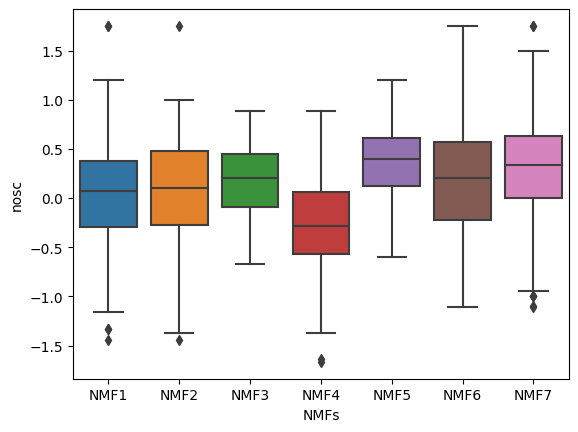

In [39]:
import seaborn as sns
df_nosc_t = pd.DataFrame({'nosc': nosc_concat,
                   'NMFs': group_concat})

sns.boxplot(x='NMFs', y='nosc', data=df_nosc_t)

In [53]:
from scipy.cluster.hierarchy import linkage, leaves_list

df_all = pd.DataFrame(columns=NMFs)
class_list = np.array(['Class'])
for cls in df_pivot_top.Class.unique():
    df_class = data_norm_t.loc[df_pivot_top.Class==cls,:]
    df_class = df_class.loc[data_norm_t.max(axis=1)>0.5,:]
    if df_class.shape[0]>2:
        Z = linkage(df_class, method='ward', metric='euclidean', optimal_ordering=True)
        df_all = pd.concat([df_all,df_class.iloc[leaves_list(Z),:]])
        class_list = np.append(class_list, np.repeat(cls, df_class.shape[0]))
    print(df_all.shape)
    print(len(class_list))

(1729, 7)
1730
(2144, 7)
2145
(2278, 7)
2279
(2313, 7)
2314
(2319, 7)
2320
(3371, 7)
3372
(3374, 7)
3375
(3417, 7)
3418
(3417, 7)
3418


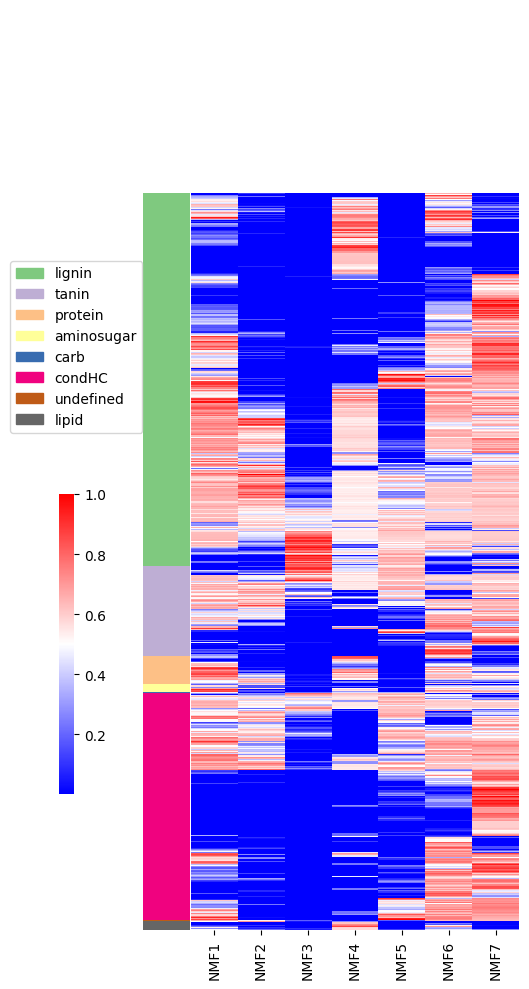

In [54]:
import seaborn as sns
colors = plt.get_cmap('Accent').colors
sp_s = class_list[1:]
lut_s = dict(zip(pd.Series(sp_s).unique(), colors))
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(df_all, figsize=(5,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=False, row_colors=rowc_s, cbar_pos=(0.05, .2, .03, .3))
#g.ax_col_dendrogram.legend(loc="upper left", bbox_to_anchor=(0.5, 1.15))
handles = [plt.Rectangle((0,0),1,1, color=lut_s[label]) for label in lut_s]
plt.legend(handles, lut_s.keys(),loc="upper right", bbox_to_anchor=(6, 1.8), ncol=1)

In [58]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
df_all = pd.DataFrame(columns=NMFs)
class_list = np.array(['Class'])
for cls in df_pivot.Class.unique():
    df_class = data_norm.loc[df_pivot.Class==cls,:]
    df_class = df_class.loc[data_norm.max(axis=1)>0.5,:]
    if df_class.shape[0]>2:
        Z = linkage(df_class, method='ward', metric='euclidean', optimal_ordering=True)
        df_all = pd.concat([df_all,df_class.iloc[leaves_list(Z),:]])
        class_list = np.append(class_list, np.repeat(cls, df_class.shape[0]))
    print(df_all.shape)
    print(len(class_list))

(1151, 5)
1152
(1513, 5)
1514
(1527, 5)
1528
(1571, 5)
1572
(1571, 5)
1572
(2214, 5)
2215
(2214, 5)
2215
(2220, 5)
2221
(2220, 5)
2221


In [57]:
df_all

,NMF1,NMF2,NMF3,NMF4,NMF5,NMF6,NMF7
C16 H20 O8,0.169388,0.198602,0.465163,0.636884,0.840242,NaN,NaN
C14 H14 O7,0.191495,0.247443,0.479646,0.643654,0.450646,NaN,NaN
C22 H26 O14,0.212219,0.661081,0.482843,0.658339,0.559078,NaN,NaN
C11 H12 O7,0.316288,0.626952,0.483840,0.639732,0.579435,NaN,NaN
C14 H18 O5 N2,0.227446,0.400297,0.450337,0.685811,0.569883,NaN,NaN
...,...,...,...,...,...,...,...
C15 H29 O4 N3,0.139572,0.000002,0.000003,0.765646,0.074795,NaN,NaN
C14 H27 O4 N3,0.136896,0.169894,0.169802,0.714111,0.407783,NaN,NaN
C11 H22 O3 N2,0.243946,0.287086,0.168166,0.708414,0.541951,NaN,NaN
C12 H24 O3 N2,0.259901,0.278683,0.267123,0.731501,0.644550,NaN,NaN


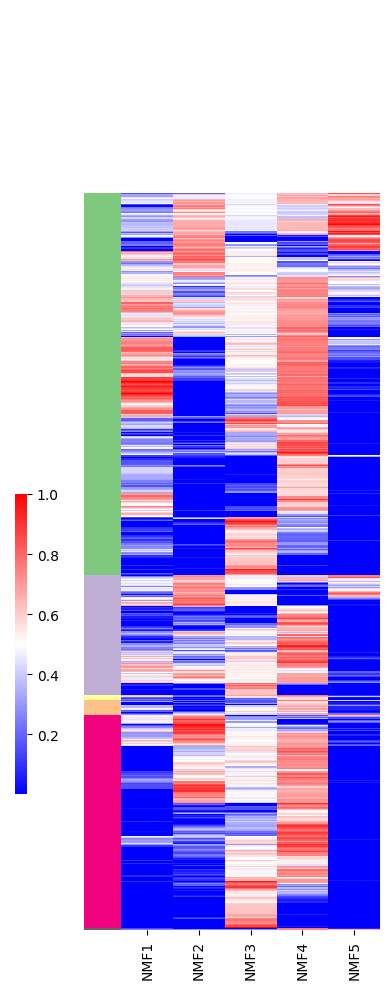

In [61]:
sp_s = class_list[1:]
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(df_all, figsize=(4,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=False, row_colors=rowc_s, cbar_pos=(0.05, .2, .03, .3))
#g.ax_col_dendrogram.legend(loc="upper left", bbox_to_anchor=(0.5, 1.15))
#handles = [plt.Rectangle((0,0),1,1, color=lut_s[label]) for label in lut_s]
#plt.legend(handles, lut_s.keys(),loc="upper right", bbox_to_anchor=(6, 1.8), ncol=1)

(557, 7)


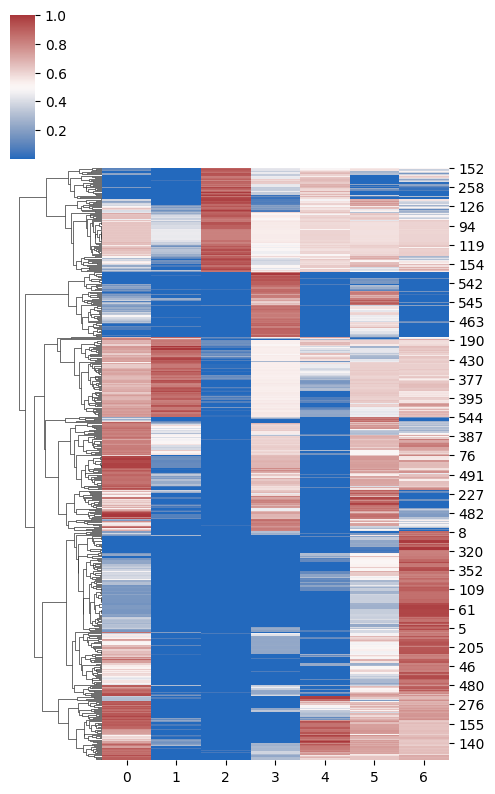

In [13]:
df_class = data_norm[df_pivot.Class=='lignin',:]
df_class = df_class[np.sum((df_class>0.8), axis=1)>0]
print(df_class.shape)

sns.clustermap(df_class, figsize=(5,8), cmap="vlag",col_cluster=False)

<AxesSubplot: >

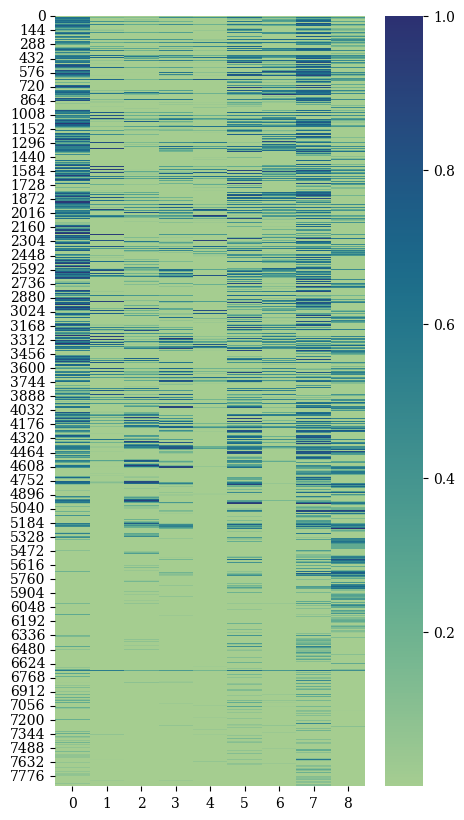

In [13]:
import seaborn as sns
plt.rc('font', family='serif')

data_norm = data/data.max(axis=0)
plt.figure(figsize=(5,10))
sns.heatmap(data_norm, cmap="crest")

In [4]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(5, 16)
(5, 16)
(5, 16)
(5, 15)
(5, 63)


In [5]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/6/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah6 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah6.shape)

(6, 16)
(6, 16)
(6, 16)
(6, 15)
(6, 63)


In [3]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


<AxesSubplot: >

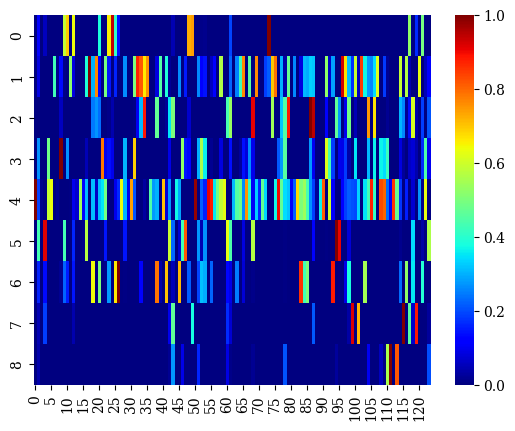

In [53]:
datah_norm = (datah.T/datah.max(axis=1)).T
sns.heatmap(datah_norm, cmap="jet")

In [8]:
nmf_grp5 = np.array([])
for i in range(datah5.shape[1]):
    nmf_grp5 = np.append(nmf_grp5, np.argmax(datah5[:,i]))

nmf_grp5

array([2., 4., 0., 0., 1., 1., 1., 0., 3., 0., 1., 0., 1., 1., 3., 0., 0.,
       0., 0., 0., 0., 4., 0., 3., 1., 3., 3., 0., 0., 0., 4., 3., 0., 0.,
       0., 0., 0., 1., 0., 3., 0., 0., 0., 0., 4., 0., 3., 3., 3., 0., 4.,
       4., 0., 0., 0., 0., 2., 2., 4., 1., 4., 1., 3.])

In [9]:
nmf_grp6 = np.array([])
for i in range(datah6.shape[1]):
    nmf_grp6 = np.append(nmf_grp6, np.argmax(datah6[:,i]))

nmf_grp6

array([4., 4., 2., 2., 5., 5., 5., 2., 4., 0., 0., 2., 5., 0., 4., 2., 0.,
       2., 2., 2., 0., 1., 0., 4., 5., 4., 4., 2., 2., 2., 1., 0., 2., 2.,
       2., 2., 2., 5., 2., 2., 2., 2., 0., 0., 1., 2., 4., 4., 4., 2., 1.,
       1., 0., 2., 2., 2., 3., 3., 1., 5., 1., 5., 4.])

In [10]:
nmf_grp7 = np.array([])
for i in range(datah7.shape[1]):
    nmf_grp7 = np.append(nmf_grp7, np.argmax(datah7[:,i]))

nmf_grp7

array([0., 0., 2., 2., 6., 6., 6., 2., 0., 4., 6., 1., 6., 4., 1., 2., 4.,
       2., 2., 2., 4., 5., 4., 0., 6., 1., 0., 2., 2., 2., 0., 4., 2., 1.,
       2., 2., 2., 6., 2., 1., 1., 2., 4., 4., 1., 2., 1., 1., 0., 1., 5.,
       5., 4., 2., 2., 2., 3., 3., 5., 6., 5., 6., 1.])

In [36]:
from sklearn.cluster import KMeans
X = df_sites_qc_btm
k_model = KMeans(3).fit(X)
print(k_model.labels_)

[0 0 1 0 1 0 0 0 1 1 1 2 2 0 0 0 0 0 2 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 2
 0 1 2 0 1 0 0 0 2 2 1 1 1 0 1 1 1 1 0 1 1 2 0 1]


In [33]:
import plotly.graph_objects as go
import numpy as np

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = ["kmeans1", "kmeans2", "kmeans3", "kmeans4", 
                "NMF5_1", "NMF5_2", "NMF5_3", "NMF5_4", "NMF5_5",
                "NMF6_1", "NMF6_2", "NMF6_3", "NMF6_4", "NMF6_5", "NMF6_6",
                "NMF7_1", "NMF7_2", "NMF7_3", "NMF7_4", "NMF7_5", "NMF7_6", "NMF7_7"],
      color = "red"
    ),
    link = dict(
      source = np.append(np.append(k_model.labels_, np.array(nmf_grp5, dtype='int')+4),np.array(nmf_grp6, dtype='int')+9), # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = np.append(np.append(np.array(nmf_grp5, dtype='int')+4, np.array(nmf_grp6, dtype='int')+9), np.array(nmf_grp7, dtype='int')+15),
      value = np.zeros(len(k_model.labels_)*3)+2
  ))])

fig.update_layout(title_text="Sankey Diagram kmeans to NMFs", font_size=15)
fig.show()

In [34]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/4/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah4 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah4.shape)
results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(4, 16)
(4, 15)
(4, 15)
(4, 15)
(4, 61)
(5, 16)
(5, 15)
(5, 15)
(5, 15)
(5, 61)


In [35]:
nmf_grp4 = np.array([])
for i in range(datah4.shape[1]):
    nmf_grp4 = np.append(nmf_grp4, np.argmax(datah4[:,i]))

print(nmf_grp4.shape)

nmf_grp5 = np.array([])
for i in range(datah5.shape[1]):
    nmf_grp5 = np.append(nmf_grp5, np.argmax(datah4[:,i]))

print(nmf_grp5.shape)

(61,)
(61,)


In [37]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = ["kmeans1", "kmeans2", "kmeans3", 
               "NMF4_1", "NMF4_2", "NMF4_3", "NMF4_4", 
                "NMF5_1", "NMF5_2", "NMF5_3", "NMF5_4", "NMF5_5"],
      color = "blue"
    ),
    link = dict(
      source = np.append(k_model.labels_, np.array(nmf_grp4, dtype='int')+3),# indices correspond to labels, eg A1, A2, A1, B1, ...
      target = np.append(np.array(nmf_grp4, dtype='int')+3, np.array(nmf_grp6, dtype='int')+7), 
      value = np.zeros(len(k_model.labels_)*2)+2
  ))])

fig.update_layout(title_text="Sankey Diagram kmeans to NMFs", font_size=20)
fig.show()

In [3]:
df_meta = pd.read_csv('/home/shic892/corems/1000s_meta_mod.csv', index_col=0, header=0)
df_meta

,Site_Name_Long,DateTime_Collected (24 Hr format),Sample_kit,Lat,Long,Elev.m,Temperatue.C,VolWaterContent.,BulkDensity
Site_Code,,,,,,,,,
ANZA,Anza Borrego Desert State Park,20220606.0,Kit 6,33.305325,-116.254011,191.0,42.7,0.049,0.000
BLAN,Blandy Experimental Farm,20200620.0,Kit 1,39.059410,-78.072070,174.0,19.7,0.174,0.029
CFS1,Organic legume disk tillage,20220404.0,Kit 2,35.382800,-78.038180,24.0,18.3,0.061,0.013
CFS2,Reduced tillage: organic,20220404.0,Kit 2,35.383290,-81.434174,24.0,23,0.073,0.004
CLBJ,Caddo Lyndon B Johnson National Grasslands,20220525.0,Kit 5,33.401641,-97.570431,274.0,18.4,0.338,0.116
...,...,...,...,...,...,...,...,...,...
REF4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BARR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BONA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_group = pd.DataFrame(columns=['site', 'depth', 'Lat', 'Long', 'NMF', 'kmeans'], index=df_sites_qc.index)
df_group['site'] = [x[0:4] for x in df_sites_qc.index.values]
df_group['depth'] = [x[5:8] for x in df_sites_qc.index.values]
df_group['Lat'] = df_meta.loc[df_group['site'].values,'Lat'].values
df_group['Long'] = df_meta.loc[df_group['site'].values,'Long'].values
#df_group['NMF'] = nmf_grp
#df_group['kmeans'] = k_model.labels_
df_group

,site,depth,Lat,Long,NMF,kmeans
short,,,,,,
ANZA_BTM,ANZA,BTM,33.305325,-116.254011,NaN,NaN
ANZA_TOP,ANZA,TOP,33.305325,-116.254011,NaN,NaN
BLAN_BTM,BLAN,BTM,39.059410,-78.072070,NaN,NaN
BLAN_TOP,BLAN,TOP,39.059410,-78.072070,NaN,NaN
CFS1_BTM,CFS1,BTM,35.382800,-78.038180,NaN,NaN
...,...,...,...,...,...,...
WY09_TOP,WY09,TOP,43.583143,-109.946757,NaN,NaN
WY10_BTM,WY10,BTM,43.582587,-109.971750,NaN,NaN
WY10_TOP,WY10,TOP,43.582587,-109.971750,NaN,NaN


In [5]:
df_top = df_group[df_group.depth=='TOP']
df_btm = df_group[df_group.depth=='BTM']

In [8]:
df_top.index[(df_top.iloc[:,2]<33.5) & (df_top.iloc[:,3]>-89)]

Index(['DELA_TOP', 'DSNY_TOP', 'JERC_TOP', 'LENO_TOP', 'OSBS_TOP', 'TALL_TOP'], dtype='object', name='short')

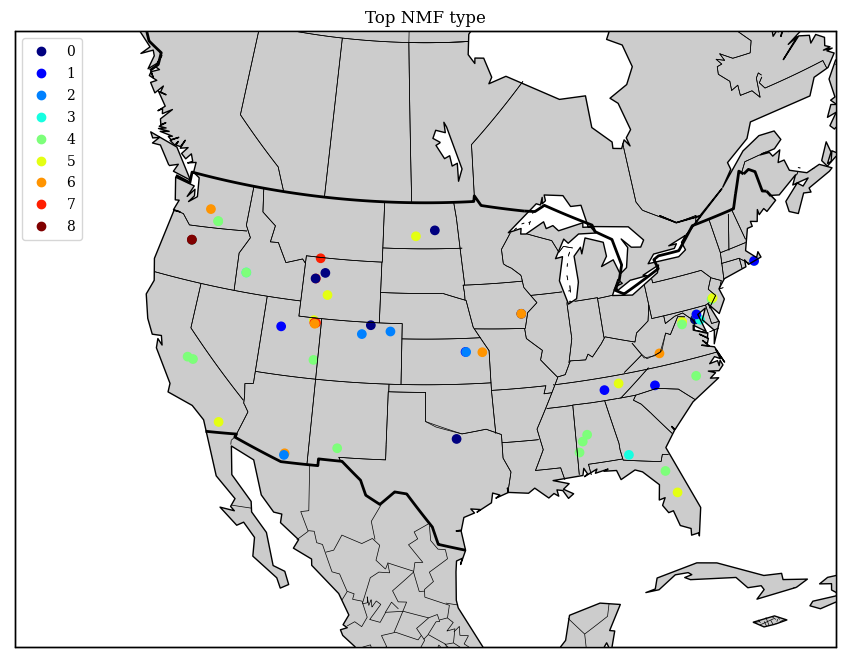

In [97]:
from mpl_toolkits.basemap import Basemap
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_top.iloc[:,3], df_top.iloc[:,2])
scatter = plt.scatter(x,y,c=df_top.iloc[:,4],cmap='jet')
plt.legend(*scatter.legend_elements())
#plt.colorbar()
plt.title("Top NMF type")
plt.show()

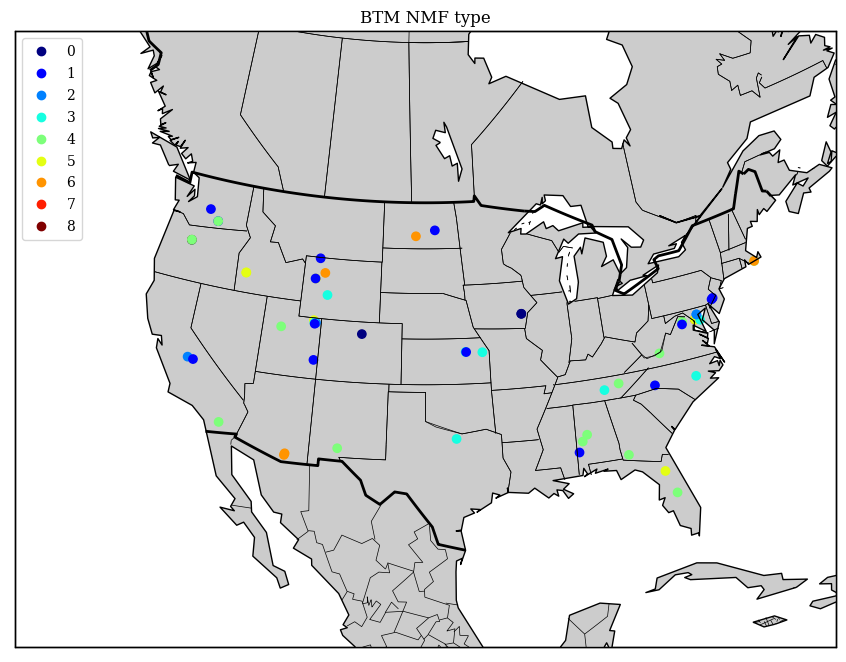

In [98]:
from mpl_toolkits.basemap import Basemap
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_btm.iloc[:,3], df_btm.iloc[:,2])
scatter = plt.scatter(x,y,c=df_btm.iloc[:,4],cmap='jet')
plt.legend(*scatter.legend_elements())
#plt.colorbar()
plt.title("BTM NMF type")
plt.show()

In [124]:
print(df_btm.NMF.unique(),
df_top.NMF.unique())


[4. 3. 1. 0. 6. 7. 5. 2. 8.] [5. 4. 1. 0. 6. 3. 2. 7. 8.]


<__array_function__ internals>:180: UserWarning: Warning: converting a masked element to nan.
/home/shic892/miniconda3/lib/python3.9/site-packages/matplotlib/colors.py:1310: UserWarning: Warning: converting a masked element to nan.
  
/home/shic892/miniconda3/lib/python3.9/site-packages/matplotlib/ticker.py:536: UserWarning: Warning: converting a masked element to nan.
  if val is None:


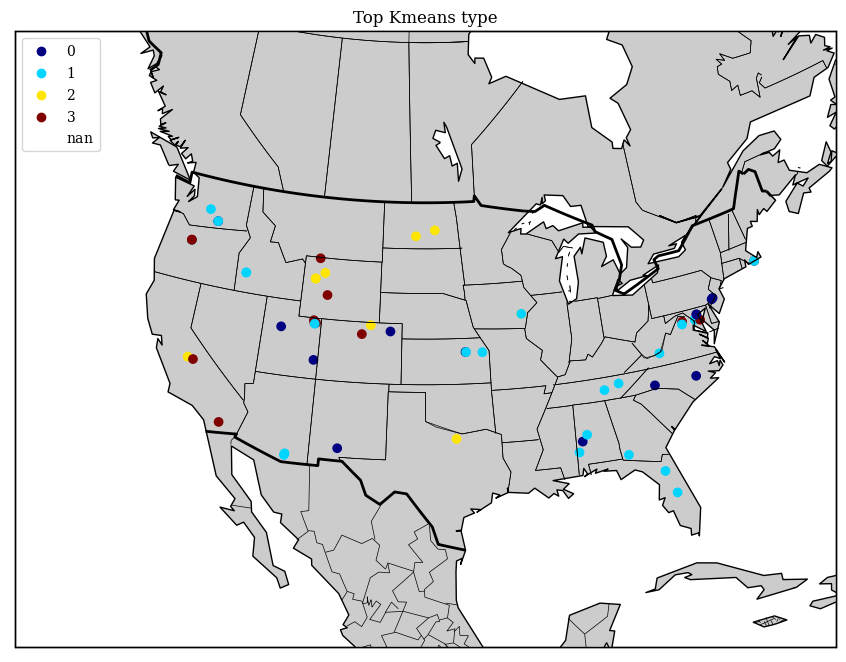

In [99]:
from mpl_toolkits.basemap import Basemap
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_top.iloc[:,3], df_top.iloc[:,2])
scatter = plt.scatter(x,y,c=df_top.iloc[:,5],cmap='jet')
plt.legend(*scatter.legend_elements())
#plt.colorbar()
plt.title("Top Kmeans type")
plt.show()

<__array_function__ internals>:180: UserWarning: Warning: converting a masked element to nan.
/home/shic892/miniconda3/lib/python3.9/site-packages/matplotlib/colors.py:1310: UserWarning: Warning: converting a masked element to nan.
  
/home/shic892/miniconda3/lib/python3.9/site-packages/matplotlib/ticker.py:536: UserWarning: Warning: converting a masked element to nan.
  if val is None:


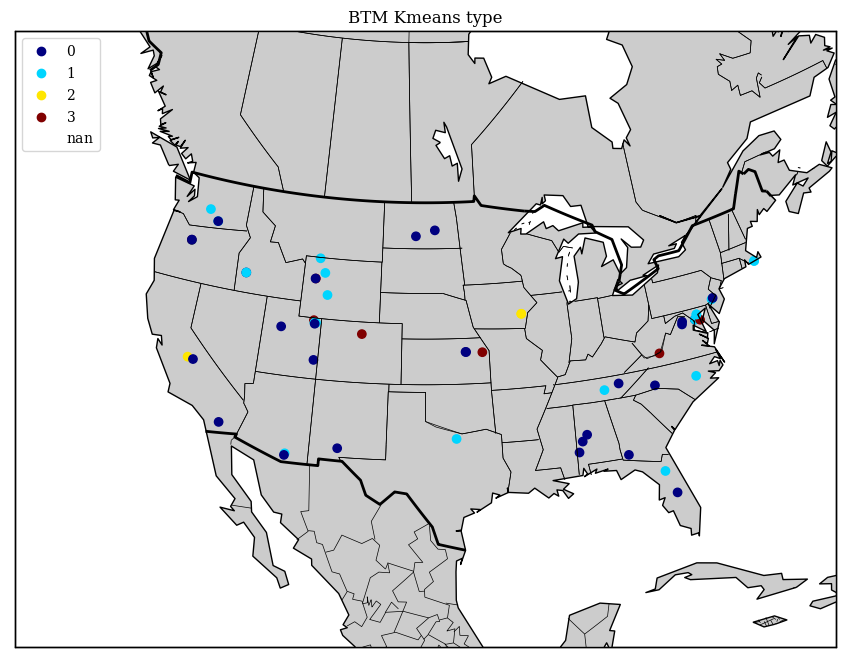

In [100]:
from mpl_toolkits.basemap import Basemap
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_btm.iloc[:,3], df_btm.iloc[:,2])
scatter = plt.scatter(x,y,c=df_btm.iloc[:,5],cmap='jet')
plt.legend(*scatter.legend_elements())
#plt.colorbar()
plt.title("BTM Kmeans type")
plt.show()

In [107]:
df_top.iloc[10,:]

site      FTA5
depth      TOP
Lat        NaN
Long       NaN
NMF        0.0
kmeans       2
Name: FTA5_TOP, dtype: object

In [96]:
print(np.nanmin(df_btm.iloc[:,3].values), np.nanmax(df_btm.iloc[:,3].values))
print(np.nanmin(df_btm.iloc[:,2].values), np.nanmax(df_btm.iloc[:,2].values))

-121.7196 -70.635356
28.125842 47.163063


In [27]:
#import pandas as pd
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_more.csv', index_col = 0,encoding='latin-1')
#df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
#df_sites_qc.shape

In [29]:
df_env['biome_name']

Sample
ANZA_BTM             Deserts & Xeric Shrublands
ANZA_TOP             Deserts & Xeric Shrublands
BLAN_BTM    Temperate Broadleaf & Mixed Forests
BLAN_TOP    Temperate Broadleaf & Mixed Forests
CFS1_BTM              Temperate Conifer Forests
                           ...                 
WY09_TOP              Temperate Conifer Forests
WY10_BTM              Temperate Conifer Forests
WY10_TOP              Temperate Conifer Forests
WY15_BTM              Temperate Conifer Forests
WY15_TOP              Temperate Conifer Forests
Name: biome_name, Length: 140, dtype: object

In [30]:
df_env.columns = [x[0:10] for x in df_env.columns]
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]

#df_env_top['nmf_grp'] = nmf_grp7
df_env_top.shape

(63, 53)

In [31]:
top_levels, top_cats = pd.factorize(df_env_top['biome_name'])

In [32]:
top_levels

array([0, 1, 2, 1, 3, 3, 3, 1, 2, 0, 0, 1, 3, 3, 2, 0, 3, 3, 1, 1, 0, 3,
       1, 1, 1, 3, 0, 0, 2, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 1, 4, 2, 0, 0,
       3, 1, 2, 3, 2, 2, 2, 2, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2])

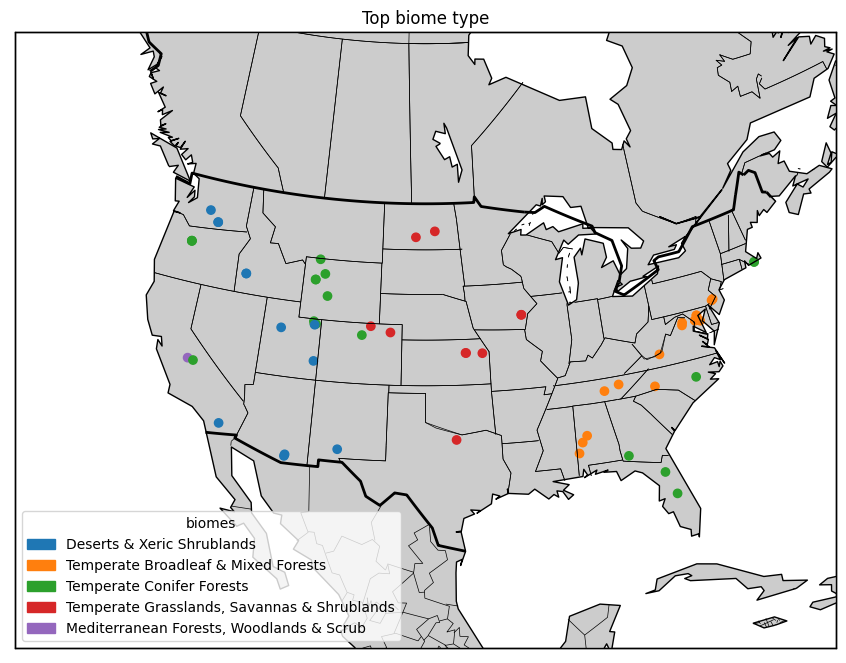

In [33]:
from mpl_toolkits.basemap import Basemap
import matplotlib.patches

fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()
colors = [plt.cm.tab10(i) for i in top_levels] # using the "tab10" colormap
handles = [matplotlib.patches.Patch(color=plt.cm.tab10(i), label=c) for i, c in enumerate(top_cats)]


x, y = m(df_top.iloc[:,3], df_top.iloc[:,2])
scatter = plt.scatter(x,y,c=colors,cmap='jet')
plt.legend(handles=handles, title='biomes')
#plt.colorbar()
plt.title("Top biome type")
plt.show()

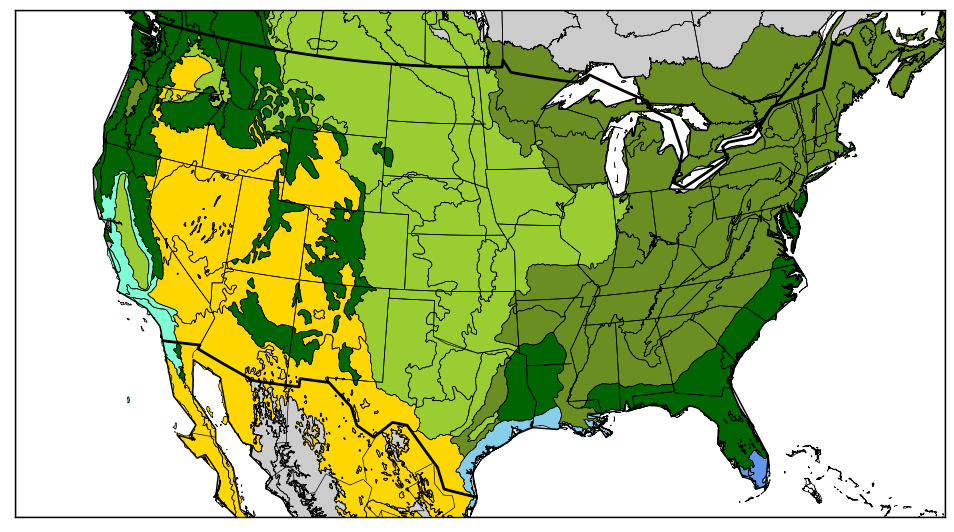

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.patches

fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=5500000,height=3000000,resolution='c',projection='aea',lon_0=-97,lat_0=38.5)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()
m.readshapefile('/home/shic892/pyDNMFk/examples/terr_biomes_ecoregions/wwf_terr_ecos', 'wwf_terr_ecos',default_encoding='iso-8859-15')
for info, shape in zip(m.wwf_terr_ecos_info, m.wwf_terr_ecos):
    if info['BIOME'] == 4.0:
        plt.fill(*zip(*shape), 'olivedrab') #"Temperate Broadleaf & Mixed Forests"
    if info['BIOME'] == 5.0:
        plt.fill(*zip(*shape), 'darkgreen') #"Temperate Conifer Forests"
    if info['BIOME'] == 8.0:
        plt.fill(*zip(*shape), 'yellowgreen') #"Temperate Grasslands, Savannas & Shrublands"
    if info['BIOME'] == 13.0:
        plt.fill(*zip(*shape), 'gold') #"Deserts & Xeric Shrublands"
    if info['BIOME'] == 12.0:
        plt.fill(*zip(*shape), 'aquamarine') #"Mediterranean Forests, Woodlands & Scrub"
    if info['BIOME'] == 9.0:
        plt.fill(*zip(*shape), 'cornflowerblue') #"Flooded Grasslands & Savannas"
    if info['BIOME'] == 7.0:
        plt.fill(*zip(*shape), 'skyblue') #"Tropical & Subtropical Grasslands, Savannas & Shrublands"

plt.show()

In [11]:
df_top.index[(df_top.iloc[:,2]<33.5) & (df_top.iloc[:,3]>-89) & (df_env_top['biome_name']=='Deserts & Xeric Shrublands')]

Index([], dtype='object', name='short')

In [17]:
df_env_top.loc[(df_top.iloc[:,2]<33.5) & (df_top.iloc[:,3]>-89),'biome_name']

Sample
DELA_TOP    Temperate Broadleaf & Mixed Forests
DSNY_TOP                                    NaN
JERC_TOP              Temperate Conifer Forests
LENO_TOP                                    NaN
OSBS_TOP              Temperate Conifer Forests
TALL_TOP                                    NaN
Name: biome_name, dtype: object

In [21]:
df_env_top.index[df_env_top['biome_name'].isnull()]

Index(['DSNY_TOP', 'FTA5_TOP', 'GRSM_TOP', 'JORN_TOP', 'LENO_TOP', 'MOAB_TOP',
       'OAES_TOP', 'SRER_TOP', 'TALL_TOP', 'TEAK_TOP', 'WY15_TOP'],
      dtype='object', name='Sample')

In [58]:
df_env_top['biome_name']

Sample
ANZA_TOP                     Deserts & Xeric Shrublands
BLAN_TOP            Temperate Broadleaf & Mixed Forests
CFS1_TOP                      Temperate Conifer Forests
CFS2_TOP            Temperate Broadleaf & Mixed Forests
CLBJ_TOP    Temperate Grasslands, Savannas & Shrublands
                               ...                     
WY01_TOP                      Temperate Conifer Forests
WY03_TOP                      Temperate Conifer Forests
WY09_TOP                      Temperate Conifer Forests
WY10_TOP                      Temperate Conifer Forests
WY15_TOP                                            NaN
Name: biome_name, Length: 63, dtype: object

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


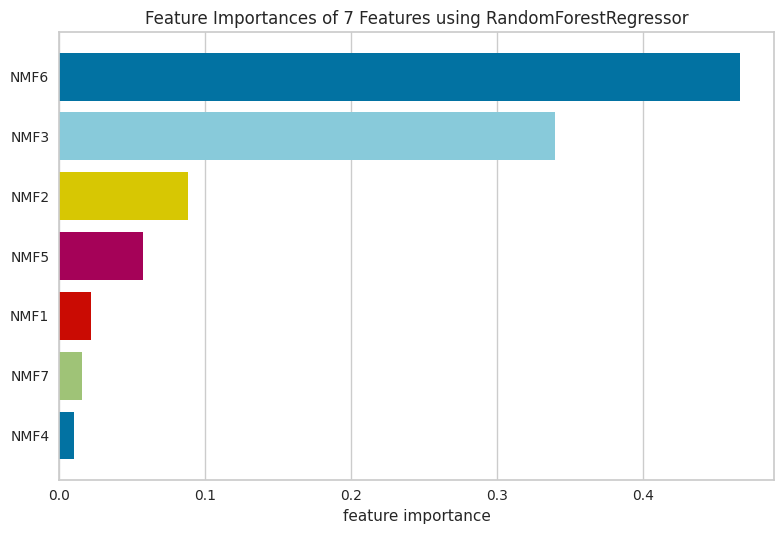

<AxesSubplot:title={'center':'Feature Importances of 7 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [41]:
from sklearn.ensemble import RandomForestRegressor
from yellowbrick.model_selection import FeatureImportances

X, y = datah7.T, df_env_top['Respiratio'].values
viz = FeatureImportances(RandomForestRegressor(), labels=['NMF1','NMF2','NMF3','NMF4','NMF5','NMF6','NMF7'], relative=False)

# Fit and show the feature importancesQ
viz.fit(X, y)
viz.show()

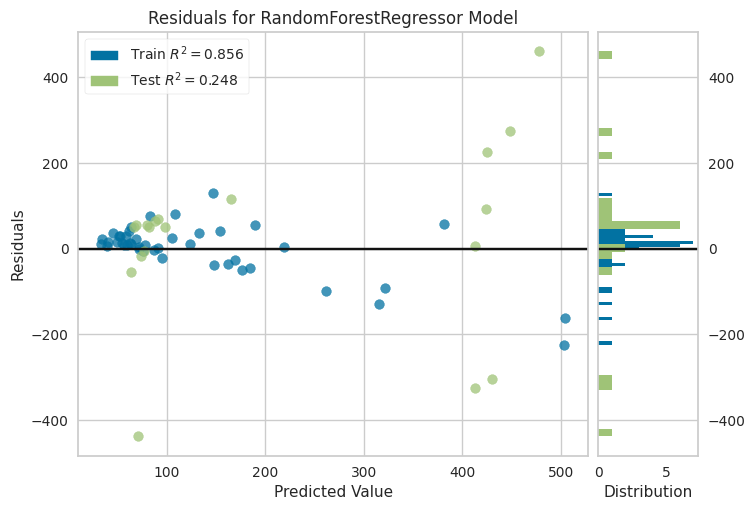

In [44]:
from yellowbrick.regressor import residuals_plot
from sklearn.model_selection import train_test_split
from yellowbrick.regressor import PredictionError, ResidualsPlot

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

viz = residuals_plot(RandomForestRegressor(), X_train, y_train, X_test, y_test)

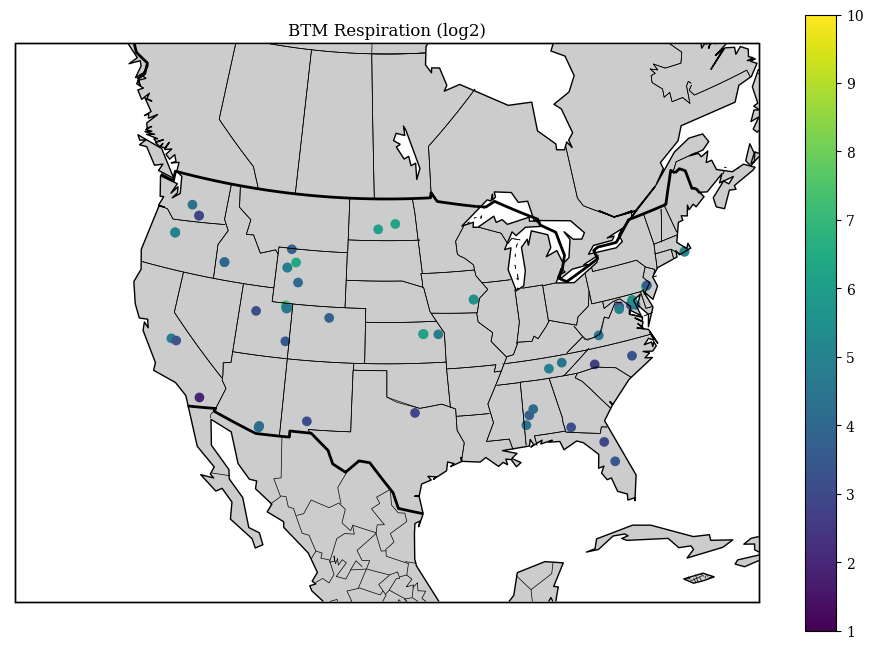

In [121]:
df_group['respiration'] = df_env['Respiratio'].values
df_top = df_group[df_group.depth=='TOP']
df_btm = df_group[df_group.depth=='BTM']

fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_btm.iloc[:,3], df_btm.iloc[:,2])
scatter = plt.scatter(x,y,c=np.log2(df_btm.iloc[:,6]),cmap='viridis',vmin=1, vmax=10)
#plt.legend(*scatter.legend_elements())
plt.colorbar()
plt.title("BTM Respiration (log2)")
plt.show()

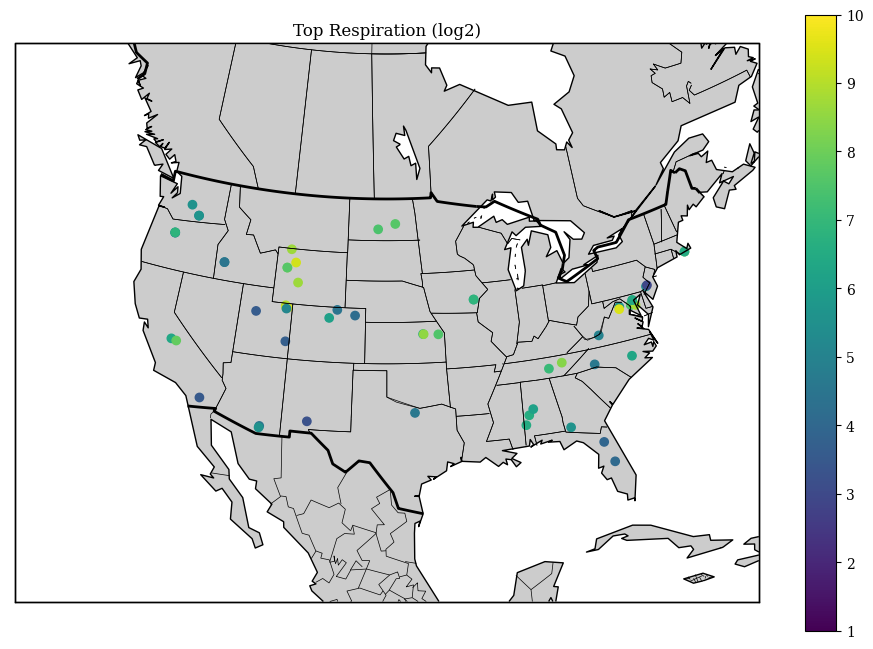

In [122]:
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

x, y = m(df_top.iloc[:,3], df_top.iloc[:,2])
scatter = plt.scatter(x,y,c=np.log2(df_top.iloc[:,6]),cmap='viridis',vmin=1, vmax=10)
#plt.legend(*scatter.legend_elements())
plt.colorbar()
plt.title("Top Respiration (log2)")
plt.show()

In [42]:
df_env.columns

Index(['mean_GWC', 'K_mg_per_k', 'SO4.S_mg_p', 'B_mg_per_k', 'Zn_mg_per_',
       'Mn_mg_per_', 'Cu_mg_per_', 'Fe_mg_per_', 'Ca_Meq_per', 'Mg_Meq_per',
       'Na_Meq_per', 'Total_Base', 'CEC_Meq_pe', 'TKN_pct', 'Total_Sulf',
       'Total_Nitr', 'Total_Carb', 'C_to_N_rat', 'NO3.N_mg_p', 'NH4.N_mg_p',
       'P_Bicarb_m', 'pH', 'B.glucosid', 'Respiratio', 'Sand_pct', 'Silt_pct',
       'Clay_pct', 'biome_name', 'nmf_grp'],
      dtype='object')

In [51]:
df_env.index.values[nmf_grp==7]

array(['NWBA_BTM', 'UT23_TOP', 'UT24_TOP', 'WY01_TOP', 'WY09_TOP'],
      dtype=object)

<AxesSubplot: xlabel='Respiratio', ylabel='nmf_grp'>

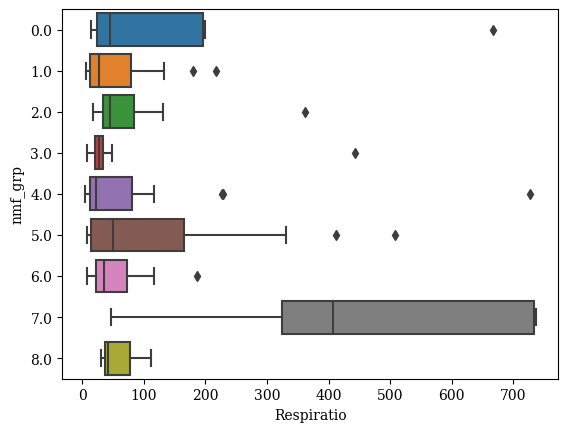

In [46]:
sns.boxplot(data=df_env, x='Respiratio', y='nmf_grp', orient="h")

<AxesSubplot: xlabel='Respiratio', ylabel='biome_name'>

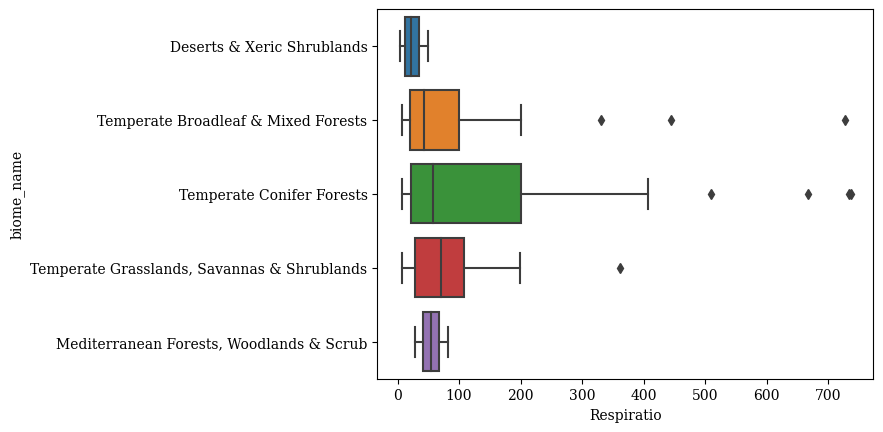

In [48]:
sns.boxplot(data=df_env, x='Respiratio', y='biome_name', orient="h")

<AxesSubplot: xlabel='mean_GWC', ylabel='nmf_grp'>

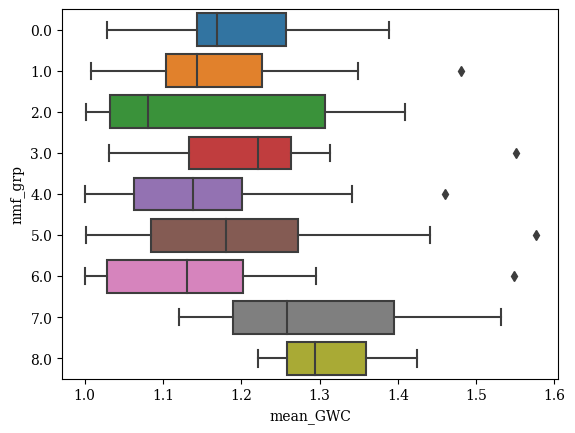

In [47]:
sns.boxplot(data=df_env, x='mean_GWC', y='nmf_grp', orient="h")